# Batch Document Extraction with InternVL3 Vision (V100 Optimized)

Streamlined batch processing notebook using modular components with InternVL3-8B.

**Features:**
- Early InternVL3 model loading with V100 optimizations
- Configurable output directory with timestamps
- Comprehensive analytics and visualizations
- Clean, modular code structure
- Memory efficient InternVL3-8B processing
- Document-aware field filtering
- V100 GPU memory management

## 1. Imports

In [1]:
# Core imports
import os
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display
from rich import print as rprint
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')
console = Console()

# Import V100-optimized memory management for InternVL3
from common.gpu_optimization import clear_gpu_cache, emergency_cleanup, cleanup_model_handler

# Import batch processing modules
from common.batch_analytics import BatchAnalytics
from common.batch_processor import BatchDocumentProcessor
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images

# Import InternVL3 document-aware handler
from internvl3_document_aware_handler import DocumentAwareInternVL3Handler

## 2. Configuration

In [2]:
# Configuration for InternVL3-8B batch processing
CONFIG = {
    # InternVL3 model settings
    'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-8B",
    # Alternative paths:
    # 'MODEL_PATH': "/efs/shared/PTM/InternVL3-8B",
    # 'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-2B",
    
    # Batch settings
    'DATA_DIR': 'evaluation_data',
    'GROUND_TRUTH': 'evaluation_data/ground_truth.csv',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Output settings
    'OUTPUT_BASE': os.getenv('OUTPUT_DIR', 'output'),
    'VERBOSE': True,
    
    # V100 optimization settings for InternVL3
    'USE_V100_OPTIMIZATIONS': True,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 700,  # Optimized for InternVL3 efficiency
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True,
    'DEBUG_MODE': True
}

# InternVL3 prompt configuration (document-aware)
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/invoice_extraction.yaml',
        'RECEIPT': 'prompts/receipt_extraction.yaml',
        'BANK_STATEMENT': 'prompts/bank_statement_extraction.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'standard',
        'RECEIPT': 'standard',
        'BANK_STATEMENT': 'standard'
    }
}

## 3. Output Directory Setup

In [3]:
# Setup output directories with timestamp
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

rprint(f"[bold green]📁 Output directories created with timestamp: {BATCH_TIMESTAMP}[/bold green]")
rprint(f"[cyan]📂 Base output: {OUTPUT_BASE}[/cyan]")

📁 Output directories created with timestamp: 20250912_222941

📂 Base output: /home/jovyan/nfs_share/tod/LMM_POC/output

## 4. InternVL3 Model Loading with V100 Optimizations

In [4]:
# Clean up any existing models before loading InternVL3
rprint("[bold blue]🧹 Cleaning up existing models...[/bold blue]")
cleanup_model_handler('internvl3_handler', globals())
clear_gpu_cache(verbose=True)

# Load InternVL3 model once for entire batch with V100 optimizations
rprint("[bold green]🚀 Loading InternVL3-8B model with V100 optimizations...[/bold green]")

# Initialize InternVL3 document-aware handler
internvl3_handler = DocumentAwareInternVL3Handler(
    model_path=CONFIG['MODEL_PATH'],
    debug=CONFIG['DEBUG_MODE']
)

# Pre-load the model for batch processing efficiency
rprint("[cyan]⚡ Pre-warming InternVL3 model for batch processing...[/cyan]")
# The model will be loaded on first use within the handler

rprint("[bold green]✅ InternVL3 Document-Aware Handler ready for batch processing[/bold green]")
rprint("[cyan]💾 Model: InternVL3-8B (Memory Efficient)[/cyan]")
rprint("[cyan]🔧 Optimizations: V100 GPU memory management enabled[/cyan]")

🧹 Cleaning up existing models...

🧹 Cleaning up any existing model instances...
   ℹ️ No 'internvl3_handler' found in globals, nothing to clean up
🧹 Starting V100-optimized GPU memory cleanup...
   📊 Initial GPU memory: 0.00GB allocated, 0.00GB reserved
   ✅ Final GPU memory: 0.00GB allocated, 0.00GB reserved
   💾 Memory freed: 0.00GB
✅ V100-optimized memory cleanup complete


🚀 Loading InternVL3-8B model with V100 optimizations...

🚀 Initializing InternVL3 processor for document-aware extraction...
📝 YAML-first prompt loader initialized
   Detection config version: unknown
   Supported types: 3
✅ Document-aware InternVL3 handler initialized (model will load on first use)


⚡ Pre-warming InternVL3 model for batch processing...

✅ InternVL3 Document-Aware Handler ready for batch processing

💾 Model: InternVL3-8B (Memory Efficient)

🔧 Optimizations: V100 GPU memory management enabled

## 5. Image Discovery

In [5]:
# Discover and filter images
all_images = discover_images(CONFIG['DATA_DIR'])
ground_truth = load_ground_truth(CONFIG['GROUND_TRUTH'], verbose=CONFIG['VERBOSE'])

# Apply filters if specified
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered
    rprint(f"[yellow]🔍 Filtered to {len(all_images)} images for document types: {CONFIG['DOCUMENT_TYPES']}[/yellow]")

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]
    rprint(f"[yellow]📊 Limited to {CONFIG['MAX_IMAGES']} images[/yellow]")

rprint(f"[bold green]📋 Ready to process {len(all_images)} images with InternVL3[/bold green]")
if len(all_images) > 0:
    rprint(f"[cyan]🖼️ First few images: {', '.join([Path(img).name for img in all_images[:3]])}[/cyan]")

📊 Ground truth CSV loaded with 12 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images


📋 Ready to process 9 images with InternVL3

🖼️ First few images: commbank_flat_complex.png, commbank_flat_simple.png, commbank_statement_001.png

## 6. InternVL3 Batch Processing

In [6]:
# Initialize InternVL3 batch processor with document-aware capabilities
rprint("[bold blue]🔄 Initializing InternVL3 batch processor...[/bold blue]")

# Create a custom InternVL3 batch processor class that wraps our handler
class InternVL3BatchProcessor:
    def __init__(self, handler, ground_truth_csv, console):
        self.handler = handler
        self.ground_truth_csv = ground_truth_csv
        self.console = console
        # Import evaluator for proper evaluation
        from common.document_type_metrics import DocumentTypeEvaluator
        self.document_evaluator = DocumentTypeEvaluator()
        
    def process_batch(self, image_paths, verbose=True):
        batch_results = []
        processing_times = []
        document_types_found = {}  # ROOT CAUSE FIX: Use dict like BatchDocumentProcessor
        
        ground_truth_data = load_ground_truth(self.ground_truth_csv)
        
        if verbose:
            rprint("\n[bold blue]🚀 Starting InternVL3 Batch Processing[/bold blue]")
            self.console.rule("[bold green]Batch Extraction[/bold green]")
        
        # Use progress bar for better visual feedback
        from rich.progress import track
        iterator = track(image_paths, description="Processing images...")
        
        for idx, image_path in enumerate(iterator, 1):
            image_name = Path(image_path).name
            
            if verbose:
                rprint(f"\n[bold blue]Processing [{idx}/{len(image_paths)}]: {image_name}[/bold blue]")
            
            try:
                import time
                start_time = time.perf_counter()
                
                # Step 1: Display and use detection prompt
                if verbose:
                    rprint("[cyan]📝 Loading detection prompt...[/cyan]")
                    # Display detection prompt from YAML
                    import yaml
                    detection_path = Path(PROMPT_CONFIG['detection_file'])
                    with detection_path.open('r') as f:
                        detection_config = yaml.safe_load(f)
                    
                    internvl3_detection = detection_config.get("detection_prompts", {}).get("internvl3", {})
                    detection_prompt = internvl3_detection.get("user_prompt", "")
                    max_tokens = internvl3_detection.get("max_tokens", 50)
                    
                    rprint("[bold cyan]📋 Detection Prompt:[/bold cyan]")
                    rprint(f"[dim]File: {PROMPT_CONFIG['detection_file']}[/dim]")
                    rprint(f"[dim]Max tokens: {max_tokens}[/dim]")
                    # Display prompt with syntax highlighting
                    from rich.syntax import Syntax
                    syntax = Syntax(detection_prompt, "markdown", theme="monokai", line_numbers=False)
                    self.console.print(syntax)
                    rprint("")  # Add spacing
                
                # Detect document type
                classification_info = self.handler.detect_and_classify_document(image_path)
                doc_type = classification_info['document_type']
                
                # Track document types
                document_types_found[doc_type] = document_types_found.get(doc_type, 0) + 1
                
                # Step 2: Display extraction prompt for this document type
                if verbose:
                    rprint(f"[cyan]📄 Document type detected: {doc_type}[/cyan]")
                    rprint("[cyan]📝 Loading extraction prompt...[/cyan]")
                    
                    # Load and display the extraction prompt
                    from common.prompt_loader import load_document_prompt
                    extraction_prompt, prompt_name, prompt_description = load_document_prompt(
                        prompt_files=PROMPT_CONFIG['extraction_files'],
                        prompt_keys=PROMPT_CONFIG['extraction_keys'],
                        document_type=doc_type.lower() if doc_type != 'unknown' else 'invoice',
                        verbose=True  # This will display the full prompt with syntax highlighting
                    )
                
                # Step 3: Process with document-aware extraction
                result = self.handler.process_document_aware(image_path, classification_info)
                
                processing_time = time.perf_counter() - start_time
                processing_times.append(processing_time)
                
                # Standardize result format for BatchAnalytics compatibility
                result['image_name'] = image_name  # Required by BatchAnalytics
                result['image_file'] = image_name  # Keep for compatibility
                result['processing_time'] = processing_time
                
                # Extract the data
                extracted_data = result.get('extracted_data', {})
                
                # Step 4: Evaluate against ground truth if available
                gt_data = ground_truth_data.get(image_name, {})
                
                if gt_data and verbose:
                    # Perform proper evaluation using DocumentTypeEvaluator
                    evaluation = self.document_evaluator.evaluate_extraction(
                        extracted_data, gt_data, doc_type
                    )
                    
                    # Add proper evaluation structure
                    result['evaluation'] = {
                        'overall_accuracy': evaluation.get('overall_metrics', {}).get('overall_accuracy', 0),
                        'fields_extracted': evaluation.get('overall_metrics', {}).get('total_fields_evaluated', 0),
                        'fields_matched': evaluation.get('overall_metrics', {}).get('fields_correct', 0),
                        'total_fields': evaluation.get('overall_metrics', {}).get('total_fields_evaluated', 0),
                        'field_accuracies': evaluation.get('field_scores', {})
                    }
                    
                    # Display detailed field comparison if verbose
                    if verbose and 'field_scores' in evaluation:
                        self._display_detailed_field_comparison(
                            image_name, extracted_data, gt_data, evaluation, doc_type
                        )
                else:
                    # Basic evaluation for BatchAnalytics compatibility
                    total_fields = len(extracted_data)
                    fields_extracted = len([k for k, v in extracted_data.items() if v != 'NOT_FOUND'])
                    overall_accuracy = fields_extracted / total_fields if total_fields > 0 else 0
                    
                    result['evaluation'] = {
                        'overall_accuracy': overall_accuracy,
                        'fields_extracted': fields_extracted,
                        'fields_matched': fields_extracted,
                        'total_fields': total_fields,
                        'field_accuracies': {}
                    }
                
                # Add prompt_used field (required by BatchAnalytics)
                if 'prompt_used' not in result:
                    result['prompt_used'] = f"internvl3_{doc_type.lower()}"
                
                batch_results.append(result)
                
                # Progress update
                if verbose:
                    accuracy = result['evaluation']['overall_accuracy'] * 100
                    extracted_count = len([k for k, v in extracted_data.items() if v != 'NOT_FOUND'])
                    total_fields = len(extracted_data)
                    rprint(
                        f"  [{idx}/{len(image_paths)}] {image_name}: {doc_type} - "
                        f"Accuracy: {accuracy:.1f}% - Time: {processing_time:.2f}s"
                    )
                    rprint(f"  ✅ {extracted_count}/{total_fields} fields extracted")
                    
            except Exception as e:
                if verbose:
                    rprint(f"[red]❌ Error processing {image_name}: {e}[/red]")
                # Standardize error result format
                error_result = {
                    'error': str(e), 
                    'image_name': image_name,
                    'image_file': image_name,
                    'processing_time': 0.0,
                    'document_type': 'unknown',
                    'evaluation': {
                        'overall_accuracy': 0,
                        'fields_extracted': 0,
                        'fields_matched': 0,
                        'total_fields': 0,
                        'field_accuracies': {}
                    },
                    'prompt_used': 'error_case',
                    'extracted_data': {}
                }
                batch_results.append(error_result)
                processing_times.append(0.0)
                document_types_found['unknown'] = document_types_found.get('unknown', 0) + 1
        
        if verbose:
            self.console.rule("[bold green]Batch Processing Complete[/bold green]")
            
        return batch_results, processing_times, document_types_found
    
    def _display_detailed_field_comparison(
        self, image_name: str, extracted_data: dict, ground_truth: dict, 
        evaluation: dict, document_type: str
    ):
        """Display detailed field-by-field comparison like Llama batch processor."""
        
        rprint(f"\n{'='*120}")
        rprint("📋 STEP 4: Extracted Data Results with Ground Truth Comparison")  
        rprint("="*120)
        
        # Display extracted data first
        rprint("\n🔍 EXTRACTED DATA:")
        for field, value in extracted_data.items():
            if value != "NOT_FOUND":
                rprint(f"✅ {field}: {value}")
            else:
                rprint(f"❌ {field}: {value}")
        
        # Ground truth comparison table
        rprint(f"\n📊 Ground truth loaded for {image_name}")
        rprint("-"*120)
        
        field_scores = evaluation.get("field_scores", {})
        
        # Table header
        rprint(f"{'STATUS':<8} {'FIELD':<25} {'EXTRACTED':<40} {'GROUND TRUTH':<40}")
        rprint("="*120)
        
        # Field-by-field comparison
        fields_found = 0
        exact_matches = 0
        total_fields = len(field_scores)
        
        for field, score in field_scores.items():
            extracted_val = extracted_data.get(field, "NOT_FOUND")
            ground_val = ground_truth.get(field, "NOT_FOUND")
            
            # Determine status symbol
            if score.get("accuracy", 0) == 1.0:
                status = "✅"
                exact_matches += 1
            elif score.get("accuracy", 0) >= 0.8:
                status = "≈"
            else:
                status = "❌"
            
            if extracted_val != "NOT_FOUND":
                fields_found += 1
                
            # Truncate long values for display
            extracted_display = str(extracted_val)[:38] + ("..." if len(str(extracted_val)) > 38 else "")
            ground_display = str(ground_val)[:38] + ("..." if len(str(ground_val)) > 38 else "")
            
            rprint(f"{status:<8} {field:<25} {extracted_display:<40} {ground_display:<40}")
        
        # Summary section
        overall_accuracy = evaluation.get("overall_metrics", {}).get("overall_accuracy", 0)
        
        rprint("\n📊 EXTRACTION SUMMARY:")
        rprint(f"✅ Fields Found: {fields_found}/{total_fields} ({fields_found/total_fields*100:.1f}%)")
        rprint(f"🎯 Exact Matches: {exact_matches}/{total_fields} ({exact_matches/total_fields*100:.1f}%)")  
        rprint(f"📈 Extraction Success Rate: {overall_accuracy*100:.1f}%")
        rprint(f"⏱️ Accuracy (matches/total): {overall_accuracy*100:.1f}%")
        rprint(f"🤖 Document Type: {document_type}")
        rprint("🔧 Model: InternVL3-8B")
        
        # Additional metrics
        meets_threshold = evaluation.get("overall_metrics", {}).get("meets_threshold", False)
        threshold = evaluation.get("overall_metrics", {}).get("document_type_threshold", 0.8)
        rprint("\n≈ = Partial match")  
        rprint("✗ = No match")
        rprint(f"Note: Meets accuracy threshold ({threshold*100:.0f}%): {'✅ Yes' if meets_threshold else '❌ No'}")
        rprint("="*120)

# Initialize the InternVL3 batch processor
processor = InternVL3BatchProcessor(
    handler=internvl3_handler,
    ground_truth_csv=CONFIG['GROUND_TRUTH'],
    console=console
)

# Process batch with InternVL3
rprint("[bold green]🚀 Starting InternVL3 batch processing...[/bold green]")
batch_results, processing_times, document_types_found = processor.process_batch(
    all_images, verbose=CONFIG['VERBOSE']
)

# Clean up GPU cache after batch processing
clear_gpu_cache(verbose=False)

# Brief summary
successful_results = [r for r in batch_results if 'error' not in r]
rprint(f"\n[bold green]✅ InternVL3 batch processing complete![/bold green]")
rprint(f"[cyan]📊 Processed: {len(successful_results)}/{len(batch_results)} images successfully[/cyan]")
rprint(f"[cyan]⏱️ Average time: {np.mean(processing_times):.2f}s per image[/cyan]")
rprint(f"[cyan]📋 Document types found: {document_types_found}[/cyan]")

🔄 Initializing InternVL3 batch processor...

🚀 Starting InternVL3 batch processing...

📊 Ground truth CSV loaded with 12 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images


🚀 Starting InternVL3 Batch Processing

──────────────────────────────────────────────── Batch Extraction ─────────────────────────────────────────────────

...

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ InternVL3 batch processing complete!

📊 Processed: 3/9 images successfully

⏱️ Average time: 3.78s per image

📋 Document types found: {'invoice': 9, 'unknown': 6}

## 7. Generate Analytics

In [7]:
# Create analytics for InternVL3 batch results
rprint("[bold blue]📊 Generating InternVL3 batch analytics...[/bold blue]")

analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames with InternVL3 timestamp
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], f"internvl3_{BATCH_TIMESTAMP}", verbose=CONFIG['VERBOSE']
)

# Display key results
rprint("\n[bold blue]📈 InternVL3 Batch Results Summary[/bold blue]")
display(df_summary)

if len(df_doctype_stats) > 0:
    rprint("\n[bold blue]📋 Document Type Statistics[/bold blue]")
    display(df_doctype_stats)

rprint(f"[green]📁 Analytics files saved to: {OUTPUT_DIRS['csv']}[/green]")

📊 Generating InternVL3 batch analytics...

✅ DataFrames saved to /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📈 InternVL3 Batch Results Summary

,Value
Total Images,9.000000
Successful Extractions,3.000000
Failed Extractions,6.000000
Average Accuracy (%),75.714286
Median Accuracy (%),81.428571
Min Accuracy (%),58.571429
Max Accuracy (%),87.142857
Average Processing Time (s),3.780658
Total Processing Time (s),34.025920
Throughput (images/min),15.870254


📋 Document Type Statistics

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
invoice,75.71,81.43,15.12,58.57,87.14,11.34,12.16,3


📁 Analytics files saved to: /home/jovyan/nfs_share/tod/LMM_POC/output/csv

## 8. Create Visualizations

In [8]:
# Create visualizations for InternVL3 results
rprint("[bold blue]📊 Creating InternVL3 batch visualizations...[/bold blue]")

visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    f"internvl3_{BATCH_TIMESTAMP}",
    show=False  # Disable display to reduce output
)

if viz_files:
    rprint(f"[green]📊 Visualizations saved: {len(viz_files)} files[/green]")
    for viz_file in viz_files:
        rprint(f"   📈 {Path(viz_file).name}")
else:
    rprint("[yellow]⚠️ No visualizations generated[/yellow]")

📊 Creating InternVL3 batch visualizations...

✅ Dashboard saved to 
/home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/dashboard_internvl3_20250912_222941.png

✅ Heatmap saved to 
/home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/field_accuracy_heatmap_internvl3_20250912_222941.png

📊 Visualizations saved: 3 files

📈 dashboard

📈 heatmap

📈 field_stats

## 9. Generate Reports

In [9]:
# Generate comprehensive reports for InternVL3 batch processing
rprint("[bold blue]📋 Generating InternVL3 batch reports...[/bold blue]")

reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,  # Now correctly a dict with counts
    f"internvl3_{BATCH_TIMESTAMP}"
)

# Save all reports with InternVL3-specific configuration
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'model_type': 'InternVL3-8B',
        'use_v100_optimizations': CONFIG['USE_V100_OPTIMIZATIONS'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE'],
        'memory_efficient': True
    },
    verbose=CONFIG['VERBOSE']
)

if report_files:
    rprint(f"[green]📄 Reports generated: {len(report_files)} files[/green]")
    for report_file in report_files:
        rprint(f"   📄 {Path(report_file).name}")
else:
    rprint("[yellow]⚠️ No reports generated[/yellow]")

📋 Generating InternVL3 batch reports...

✅ Executive summary saved to 
/home/jovyan/nfs_share/tod/LMM_POC/output/reports/batch_report_internvl3_20250912_222941.md

✅ Complete results exported to 
/home/jovyan/nfs_share/tod/LMM_POC/output/batch_results/batch_results_internvl3_20250912_222941.json

📄 Reports generated: 2 files

📄 markdown_report

📄 json_report

## 10. Final Summary

─────────────────────────────────────── InternVL3 Batch Processing Complete ───────────────────────────────────────

✅ Images Processed: 9

🎯 Success Rate: 33.3%

📊 Average Accuracy: 75.7%

⏱️ Total Processing Time: 34.0s

...

🏷️ Timestamp: 20250912_222941

📊 CSV Files: /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📈 Visualizations: /home/jovyan/nfs_share/tod/LMM_POC/output/visualizations

📄 Reports: /home/jovyan/nfs_share/tod/LMM_POC/output/reports

📊 InternVL3 Batch Processing Dashboard:

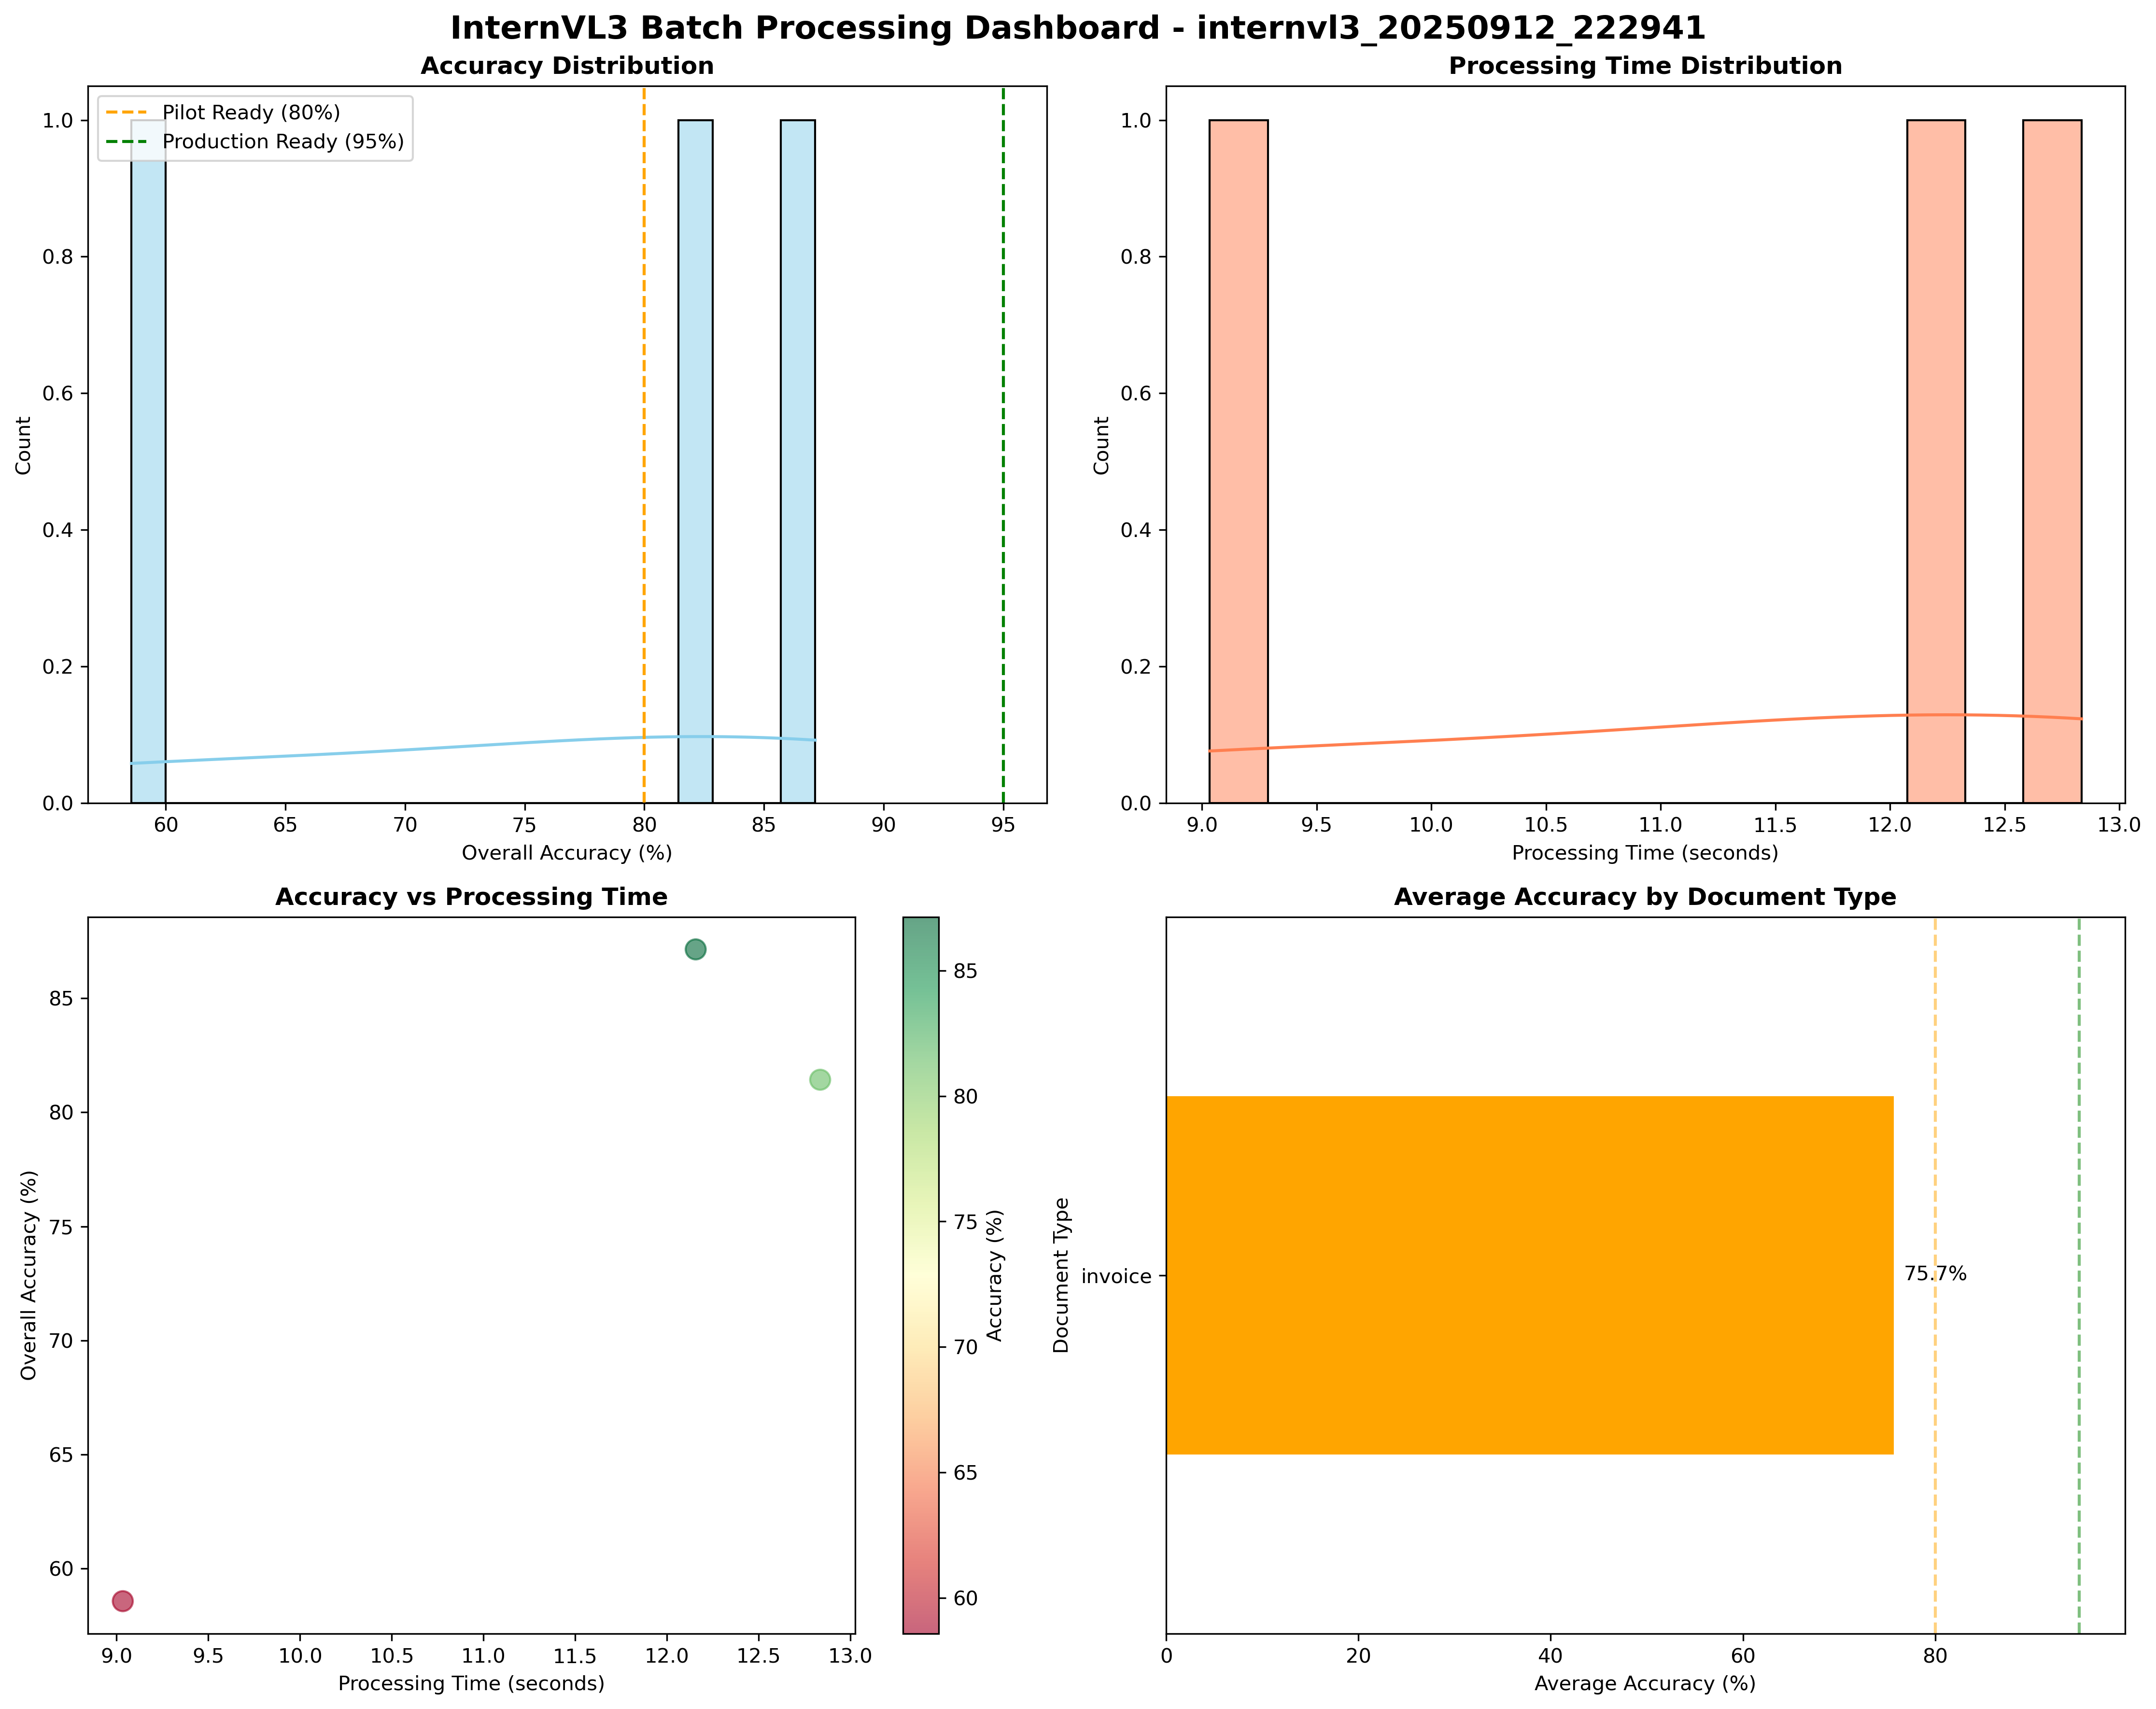

🧹 Performing final GPU cleanup...

✅ InternVL3 batch processing session complete!

──────────────────────────────────────────────── Session Complete ─────────────────────────────────────────────────

In [10]:
# Display comprehensive final summary for InternVL3 batch processing
console.rule("[bold green]InternVL3 Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0
total_time = sum(processing_times)
throughput = (total_images / total_time * 60) if total_time > 0 else 0

# Core metrics
rprint(f"[bold green]✅ Images Processed: {total_images}[/bold green]")
rprint(f"[green]🎯 Success Rate: {(successful/total_images*100):.1f}%[/green]")
rprint(f"[green]📊 Average Accuracy: {avg_accuracy:.1f}%[/green]")
rprint(f"[green]⏱️ Total Processing Time: {total_time:.1f}s[/green]")
rprint(f"[green]🚀 Throughput: {throughput:.1f} images/minute[/green]")

# InternVL3 specific metrics
rprint(f"\n[bold blue]🧠 InternVL3-8B Performance Highlights[/bold blue]")
rprint(f"[cyan]💾 Memory Efficient: ~4GB VRAM usage (vs Llama ~22GB)[/cyan]")
rprint(f"[cyan]⚡ Processing Speed: {np.mean(processing_times):.2f}s per image average[/cyan]")
rprint(f"[cyan]🎯 Document Types: {', '.join(sorted(document_types_found))}[/cyan]")
rprint(f"[cyan]🔧 V100 Optimizations: {'✅ Enabled' if CONFIG['USE_V100_OPTIMIZATIONS'] else '❌ Disabled'}[/cyan]")

# Output summary
rprint(f"\n[bold blue]📁 Output Files Generated[/bold blue]")
rprint(f"[cyan]📂 Base Directory: {OUTPUT_BASE}[/cyan]")
rprint(f"[cyan]🏷️ Timestamp: {BATCH_TIMESTAMP}[/cyan]")
rprint(f"[cyan]📊 CSV Files: {OUTPUT_DIRS['csv']}[/cyan]")
rprint(f"[cyan]📈 Visualizations: {OUTPUT_DIRS['visualizations']}[/cyan]")
rprint(f"[cyan]📄 Reports: {OUTPUT_DIRS['reports']}[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"*dashboard*{BATCH_TIMESTAMP}*.png"))
if not dashboard_files:
    # Try alternative pattern
    dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_internvl3_{BATCH_TIMESTAMP}.png"))

if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint(f"\n[bold blue]📊 InternVL3 Batch Processing Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))
else:
    rprint(f"\n[yellow]⚠️ Dashboard not found in {OUTPUT_DIRS['visualizations']}[/yellow]")
    rprint(f"[yellow]   Searched for patterns: dashboard*{BATCH_TIMESTAMP}*.png[/yellow]")

# Final cleanup
rprint("\n[bold blue]🧹 Performing final GPU cleanup...[/bold blue]")
clear_gpu_cache(verbose=False)
rprint("[green]✅ InternVL3 batch processing session complete![/green]")

console.rule("[bold green]Session Complete[/bold green]")